Generated points (X):
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]
 [0.02058449 0.96990985]
 [0.83244264 0.21233911]
 [0.18182497 0.18340451]
 [0.30424224 0.52475643]
 [0.43194502 0.29122914]]

Shape of X: (10, 2)


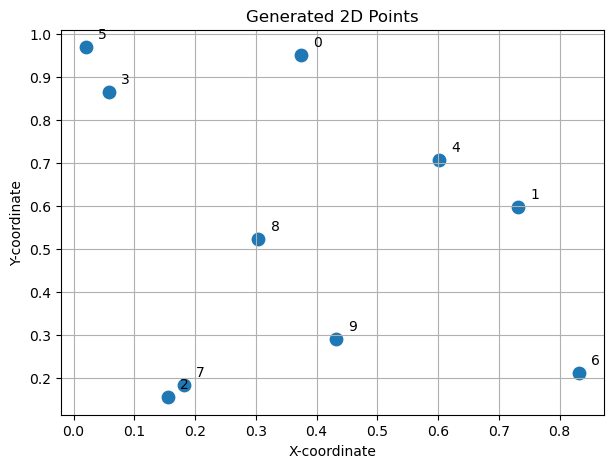

Shape of coordinate differences: (10, 10, 2)
Shape of squared differences: (10, 10, 2)
Shape of squared distance matrix: (10, 10)

Pairwise Squared Distance Matrix:
[[0.         0.25171654 0.67933117 0.10729142 0.11021119 0.12565305
  0.75487265 0.62590345 0.1863819  0.43821601]
 [0.25171654 0.         0.52769893 0.52572083 0.02910074 0.64393098
  0.1593326  0.47512176 0.18843303 0.18454216]
 [0.67933117 0.52769893 0.         0.51394921 0.50290096 0.68080058
  0.46072414 0.00141727 0.15795558 0.09442377]
 [0.10729142 0.52572083 0.51394921 0.         0.31987984 0.01216687
  1.02713477 0.48148903 0.17716149 0.47033641]
 [0.11021119 0.02910074 0.50290096 0.31987984 0.         0.40557444
  0.29926414 0.45108072 0.12173825 0.20237694]
 [0.12565305 0.64393098 0.68080058 0.01216687 0.40557444 0.
  1.23302708 0.64458914 0.27862329 0.62982499]
 [0.75487265 0.1593326  0.46072414 1.02713477 0.29926414 1.23302708
  0.         0.42414057 0.37660024 0.16662198]
 [0.62590345 0.47512176 0.00141727 0.4

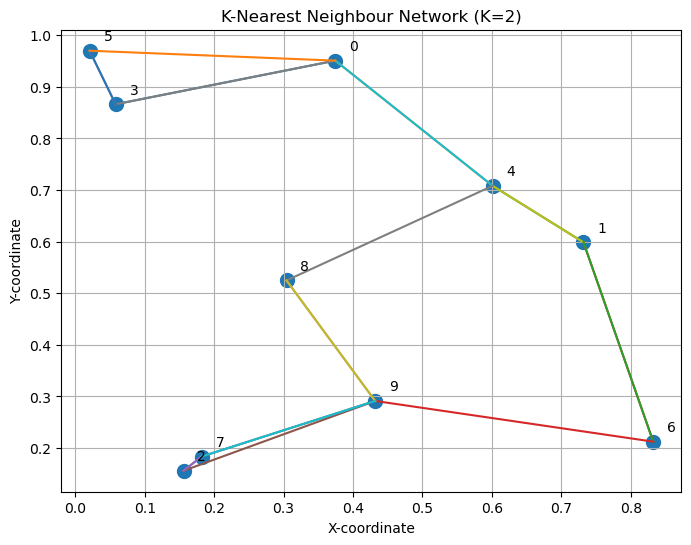

Performance Comparison
--------------------------------------------------

N = 100
3.36 ms ± 340 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.31 ms ± 57.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Loop-based average time: 0.0033558185714290243
Vectorized average time: 0.001309725871428652

N = 1000
141 ms ± 40.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
84.5 ms ± 15.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Loop-based average time: 0.14101332428570978
Vectorized average time: 0.08450275714285453

N = 5000
4.5 s ± 89.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.15 s ± 68.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Loop-based average time: 4.498935542857128
Vectorized average time: 2.150857428571466


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed random seed for reproducible results
np.random.seed(42)

# Generate 10 random points in 2D
X = np.random.rand(10, 2)

# Display the generated points
print("Generated points (X):")
print(X)

# Display the shape
print("\nShape of X:", X.shape)

# Plot the points
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=80)

# Label each point
for i in range(len(X)):
    plt.text(X[i, 0] + 0.02, X[i, 1] + 0.02, str(i), fontsize=10)

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Generated 2D Points")
plt.grid(True)
plt.show()

# STEP 2: Pairwise Squared Distances

# Single-line broadcasting calculation
D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)

# Breaking the calculation into 3 steps
diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
squared_diff = diff ** 2
D2_steps = np.sum(squared_diff, axis=2)

# Print shapes
print("Shape of coordinate differences:", diff.shape)
print("Shape of squared differences:", squared_diff.shape)
print("Shape of squared distance matrix:", D2_steps.shape)

# Print the distance matrix
print("\nPairwise Squared Distance Matrix:")
print(D2_steps)

# Verify both methods give the same result
print("\nBoth calculations are equal:", np.allclose(D2, D2_steps))

# Check diagonal elements
diagonal = np.diag(D2)

print("Diagonal elements:")
print(diagonal)

# Check whether all diagonal elements are zero
print("\nAre all diagonal elements zero?",
      np.allclose(diagonal, 0))

# Check whether distance matrix is symmetric
print("Is the distance matrix symmetric?",
      np.allclose(D2, D2.T))


# Full sorting of distances
neighbor_order = np.argsort(D2, axis=1)

print("Neighbor ordering:")
print(neighbor_order)

# The first column represents the point itself
print("\nFirst column:")
print(neighbor_order[:, 0])

# K = 2
K = 2

# Find K+1 smallest distances because the point itself is included
nearest_indices = np.argpartition(D2, K + 1, axis=1)[:, :K + 1]

print("\nK+1 nearest indices including the point itself:")
print(nearest_indices)

# Remove the point itself
knn_indices = np.zeros((len(X), K), dtype=int)

for i in range(len(X)):
    row = nearest_indices[i]
    row = row[row != i]
    knn_indices[i] = row[:K]

print("\nTwo nearest neighbors of every point:")
print(knn_indices)


plt.figure(figsize=(8, 6))

# Plot points
plt.scatter(X[:, 0], X[:, 1], s=100)

# Label points
for i in range(len(X)):
    plt.text(
        X[i, 0] + 0.02,
        X[i, 1] + 0.02,
        str(i),
        fontsize=10
    )

# Draw lines to the two nearest neighbors
for i in range(len(X)):
    for j in knn_indices[i]:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]]
        )

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("K-Nearest Neighbour Network (K=2)")
plt.grid(True)
plt.show()




import numpy as np

# Loop-based implementation
def loop_knn(X, K=2):
    N = len(X)
    neighbors = np.zeros((N, K), dtype=int)

    for i in range(N):
        distances = np.sum((X - X[i]) ** 2, axis=1)
        order = np.argsort(distances)
        neighbors[i] = order[1:K+1]

    return neighbors


# Vectorized implementation
def vectorized_knn(X, K=2):
    D2 = np.sum(
        (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
        axis=2
    )

    nearest = np.argpartition(D2, K + 1, axis=1)[:, :K+1]

    neighbors = np.zeros((len(X), K), dtype=int)

    for i in range(len(X)):
        row = nearest[i]
        row = row[row != i]
        neighbors[i] = row[:K]

    return neighbors


# Performance comparison
sizes = [100, 1000, 5000]

print("Performance Comparison")
print("-" * 50)

for N in sizes:

    np.random.seed(42)
    X_test = np.random.rand(N, 2)

    print("\nN =", N)

    loop_time = %timeit -o loop_knn(X_test, 2)
    vector_time = %timeit -o vectorized_knn(X_test, 2)

    print("Loop-based average time:", loop_time.average)
    print("Vectorized average time:", vector_time.average)



In [4]:
from sklearn.neighbors import KDTree
import time

# Generate 1000 points
np.random.seed(42)
X_bonus = np.random.rand(1000, 2)

K = 2

# KDTree
start = time.perf_counter()

tree = KDTree(X_bonus)
distances_tree, indices_tree = tree.query(X_bonus, k=K+1)

tree_time = time.perf_counter() - start

# NumPy vectorized method
start = time.perf_counter()

D2_bonus = np.sum(
    (X_bonus[:, np.newaxis, :] - X_bonus[np.newaxis, :, :]) ** 2,
    axis=2
)

indices_numpy = np.argpartition(
    D2_bonus, K + 1, axis=1
)[:, :K+1]

numpy_time = time.perf_counter() - start

print("KDTree runtime:", tree_time, "seconds")
print("NumPy runtime:", numpy_time, "seconds")

print("\nKDTree nearest neighbors for first 5 points:")
print(indices_tree[:5])

print("\nNumPy nearest neighbors for first 5 points:")
print(indices_numpy[:5])

KDTree runtime: 0.007090900000548572 seconds
NumPy runtime: 0.08678120000058698 seconds

KDTree nearest neighbors for first 5 points:
[[  0  69 357]
 [  1 231 797]
 [  2 700 416]
 [  3 264 597]
 [  4 699 640]]

NumPy nearest neighbors for first 5 points:
[[357  69   0]
 [  1 231 797]
 [416 700   2]
 [264   3 597]
 [  4 699 640]]


In [6]:
# Verify that the K nearest neighbors exclude the point itself
print("Self-neighbor check:")

for i in range(len(X)):
    print(
        "Point", i,
        "-> Neighbors:", knn_indices[i],
        "| Self included:", i in knn_indices[i]
    )

Self-neighbor check:
Point 0 -> Neighbors: [3 4] | Self included: False
Point 1 -> Neighbors: [4 6] | Self included: False
Point 2 -> Neighbors: [7 9] | Self included: False
Point 3 -> Neighbors: [5 0] | Self included: False
Point 4 -> Neighbors: [1 0] | Self included: False
Point 5 -> Neighbors: [3 0] | Self included: False
Point 6 -> Neighbors: [1 9] | Self included: False
Point 7 -> Neighbors: [2 9] | Self included: False
Point 8 -> Neighbors: [9 4] | Self included: False
Point 9 -> Neighbors: [8 7] | Self included: False
